In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('husl')

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# Load the preprocessed data saved from Feature-Engineering notebook
df_train = pd.read_csv('./data/data/processed/train_processed_advanced.csv')

print(f'Shape: {df_train.shape}')
print(f'Columns: {df_train.columns.tolist()}')
df_train.head()

Shape: (336715, 35)
Columns: ['src_bytes', 'total_bytes', 'log_src_bytes', 'diff_srv_rate', 'src_bytes_ratio', 'same_srv_rate', 'flag_SF', 'count', 'dst_host_same_src_port_rate', 'serror_rate', 'log_dst_bytes', 'dst_host_diff_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_bytes', 'service_freq', 'srv_count', 'protocol_type_icmp', 'is_error_flag', 'dst_host_count', 'dst_host_rerror_rate', 'dst_host_srv_diff_host_rate', 'logged_in', 'protocol_type_tcp', 'hot', 'wrong_fragment', 'rerror_rate', 'num_compromised', 'flag_RSTR', 'srv_diff_host_rate', 'duration', 'flag_REJ', 'log_duration', 'protocol_type_udp', 'attack_class']


,src_bytes,total_bytes,log_src_bytes,diff_srv_rate,src_bytes_ratio,same_srv_rate,flag_SF,count,dst_host_same_src_port_rate,serror_rate,...,wrong_fragment,rerror_rate,num_compromised,flag_RSTR,srv_diff_host_rate,duration,flag_REJ,log_duration,protocol_type_udp,attack_class
0,1.619565,0.264915,0.425286,0.000000,1.830140,0.000000,0.0,-0.085106,2.833333,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,4
1,0.369565,0.019886,0.210485,2.500000,1.830140,-1.010989,0.0,-0.007092,14.666667,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0,4
2,-0.159420,-0.083807,-0.676858,1.166667,-0.169860,-1.043956,-1.0,0.773050,0.000000,1.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0
3,0.681159,5.871449,0.292385,0.000000,-0.114523,0.000000,0.0,-0.063830,0.500000,0.2,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,4
4,0.561594,0.355824,0.265229,0.000000,0.473113,0.000000,0.0,0.113475,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.09,0.0,0.0,0.0,0.0,4


In [3]:
# Separate features and target
X_resampled = df_train.drop(columns=['attack_class'])
y_raw = df_train['attack_class']

print(f'X_resampled shape : {X_resampled.shape}')
print(f'y_raw distribution:\n{y_raw.value_counts()}')

X_resampled shape : (336715, 34)
y_raw distribution:
attack_class
4    67343
0    67343
2    67343
1    67343
3    67343
Name: count, dtype: int64


In [4]:
# Encode the target labels
data = y_raw

var = LabelEncoder()
data = var.fit_transform(data)

In [5]:
# Train lightweight Random Forest for feature importance
parameter = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
parameter.fit(X_resampled, data)

print('Random Forest trained successfully.')
print(f'Number of trees : {parameter.n_estimators}')
print(f'Max depth       : {parameter.max_depth}')

Random Forest trained successfully.
Number of trees : 100
Max depth       : 10


In [6]:
# Create a Series of feature importances
v = pd.Series(parameter.feature_importances_, index=X_resampled.columns)
importance = v.sort_values(ascending=False)

print('Top 25 Features by Importance:')
print(importance.head(25).to_string())

Top 25 Features by Importance:
total_bytes                    0.086594
service_freq                   0.081984
src_bytes                      0.065579
dst_host_srv_count             0.062480
logged_in                      0.056318
log_src_bytes                  0.051514
log_dst_bytes                  0.049658
dst_bytes                      0.047335
dst_host_same_src_port_rate    0.043040
src_bytes_ratio                0.042512
dst_host_diff_srv_rate         0.042363
srv_count                      0.039559
count                          0.038657
serror_rate                    0.034534
hot                            0.028936
log_duration                   0.025275
diff_srv_rate                  0.022873
num_compromised                0.021829
duration                       0.020731
is_error_flag                  0.019461
dst_host_same_srv_rate         0.019006
dst_host_count                 0.015882
same_srv_rate                  0.014658
protocol_type_tcp              0.011629
flag_SF  

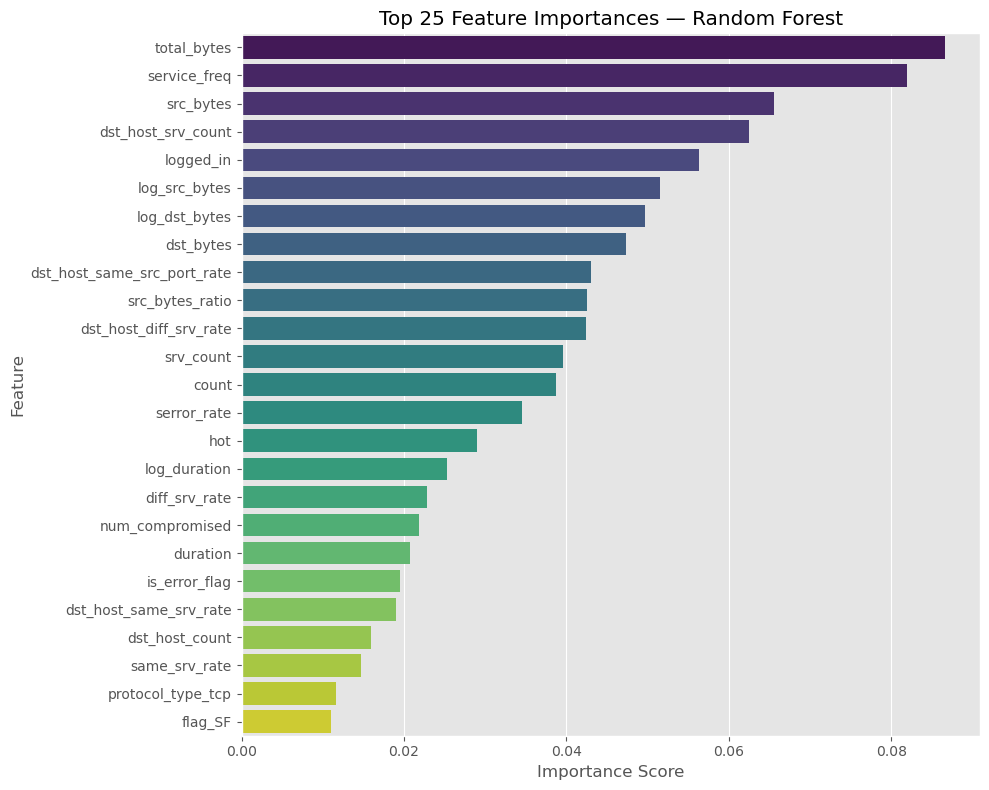

In [7]:
# Plot top 25 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x=importance.head(25).values, y=importance.head(25).index, palette='viridis')
plt.title('Top 25 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [8]:
# Set threshold and identify low importance features
threshold      = 0.001
low_importance = importance[importance < threshold]

print(f'Threshold value : {threshold}')
print(f'Total features  : {len(importance)}')
print(f'Low importance features (< {threshold}): {len(low_importance)}')
print(f'\nLow importance features:')
print(low_importance.to_string())

Threshold value : 0.001
Total features  : 34
Low importance features (< 0.001): 0

Low importance features:
Series([], )


In [9]:
# Selected features — above threshold
selected_features = importance[importance >= threshold].index.tolist()

print(f'Features kept(>={threshold}) : {len(selected_features)}')
print(f'Features dropped(<{threshold}) : {len(low_importance)}')

Features kept(>=0.001) : 34
Features dropped(<0.001) : 0


In [10]:
# Selected features — above threshold
selected_features = importance[importance >= threshold].index.tolist()

print(f'Features kept(>={threshold}) : {len(selected_features)}')
print(f'Features dropped(<{threshold}) : {len(low_importance)}')

Features kept(>=0.001) : 34
Features dropped(<0.001) : 0


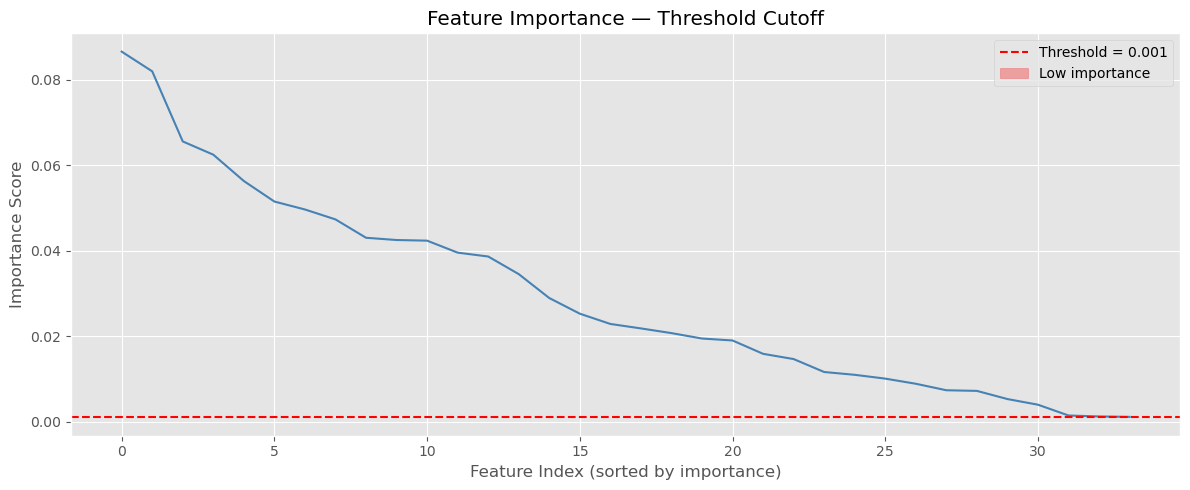

In [11]:
# Plot showing threshold cutoff
plt.figure(figsize=(12, 5))
plt.plot(range(len(importance)), importance.values, color='steelblue')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.fill_between(range(len(importance)), importance.values, threshold,
                 where=importance.values < threshold, color='red', alpha=0.3, label='Low importance')
plt.title('Feature Importance — Threshold Cutoff')
plt.xlabel('Feature Index (sorted by importance)')
plt.ylabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

Running t-SNE on 3000 samples...


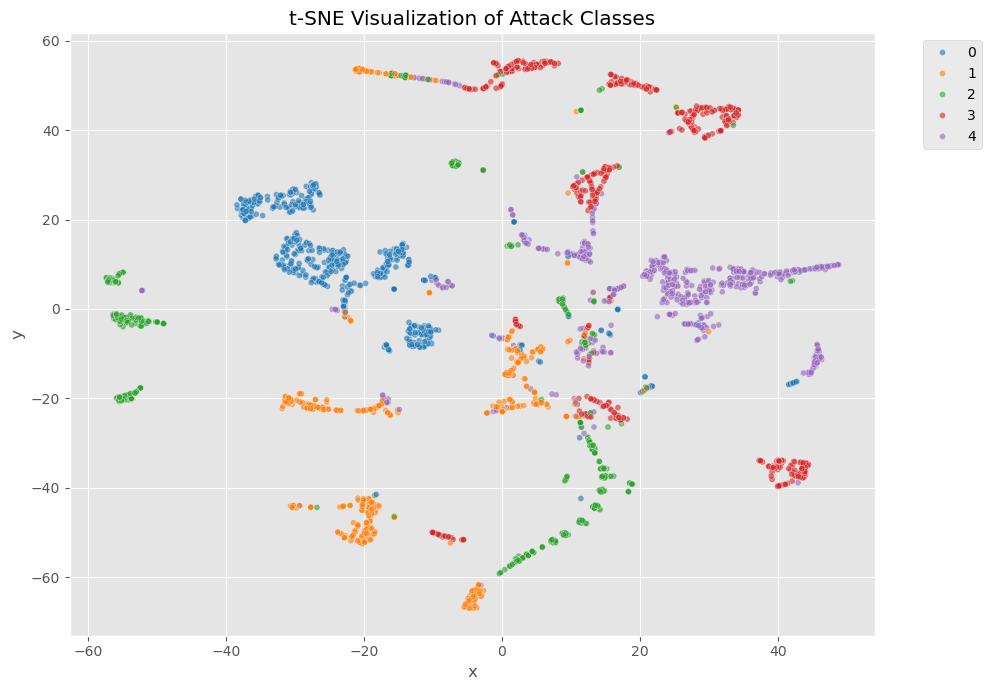

In [17]:
# T-SNE Visualization
from sklearn.manifold import TSNE

# Sample 3000 rows — t-SNE is slow on large data
samplesize = 3000
rows       = np.random.choice(len(X_resampled), samplesize, replace=False)

x_sample = X_resampled.iloc[rows]
y_sample = data[rows]

print(f'Running t-SNE on {samplesize} samples...')

# Fit t-SNE
t        = TSNE(n_components=2, perplexity=40, n_iter=1000, learning_rate='auto', init='pca', random_state=42)
t_result = t.fit_transform(x_sample)

# Build DataFrame for plotting
tsne_df = pd.DataFrame({
    'x'    : t_result[:, 0],
    'y'    : t_result[:, 1],
    'class': y_sample
})

# Map encoded numbers back to class names using your LabelEncoder 'var'
tsne_df['class'] = tsne_df['class'].map(dict(enumerate(var.classes_)))

# Color palette
color = {
    'normal' : '#2196F3',
    'DoS'    : '#F44336',
    'Probe'  : '#4CAF50',
    'R2L'    : '#FF9800',
    'U2R'    : '#9C27B0'
}

import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tsne_df,
    x='x',
    y='y',
    hue='class',
    palette='tab10',
    alpha=0.6,
    s=20
)

plt.title('t-SNE Visualization of Attack Classes')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()